# Nepali Vehicle Classification: Kathmandu Road Safety

**Dataset:** [Nepali Vehicle Dataset (Kaggle)](https://www.kaggle.com/datasets/aryalrupesh/nepli-vehicle-dataset)


1. Environment setup + Google Drive dataset loading
2. Exploratory Data Analysis (class balance, sample images, image sizes)
3. Stratified train/val/test split
4. `ImageDataGenerator` pipeline (augmentation for train, rescale-only for val/test)
5. **Two supervised architectures**: a from-scratch `Sequential` CNN baseline, and a **transfer-learning**
   model (EfficientNetB0, ImageNet-pretrained, two-phase fine-tuning)
6. Training with Keras callbacks: `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`, plus dropout,
   batch normalisation, L2 weight decay, data augmentation, and class-weighted loss
7. Full evaluation: accuracy, macro-F1, confusion matrix, per-class report
8. **Error analysis**: most-confused class pairs + grid of most-confidently-wrong predictions
9. **Ablation study**: isolates the effect of each technique
10. Final results summary + model export



## 1. Setup

In [1]:
!pip install -q scikit-learn seaborn --upgrade
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.9 MB/s eta 0:00:00
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.1 Mount Google Drive



In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 1.2 Point to the dataset in Drive


In [3]:
import os, zipfile, shutil
from pathlib import Path

DRIVE_DATASET_PATH = "/content/drive/MyDrive/Nepali_vehicle_dataset"

LOCAL_RAW_DIR = Path("/content/data/raw")
LOCAL_RAW_DIR.mkdir(parents=True, exist_ok=True)



print("\n---- Top-level structure under /content/data/raw ----")
for p in sorted(LOCAL_RAW_DIR.rglob("*")):
    if p.is_dir() and len(p.relative_to(LOCAL_RAW_DIR).parts) <= 2:
        print(p)



---- Top-level structure under /content/data/raw ----


 This dataset's actual layout (per class folder)

In [ ]:
RAW_DIR = "/content//drive/MyDrive/Nepali_vehicle_dataset"
assert os.path.isdir(RAW_DIR), f"{RAW_DIR} does not exist fix RAW_DIR based on the printed tree above."
class_folders = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])
print(f"Found {len(class_folders)} class folders:")
print(class_folders)


Found 11 class folders:
['ambulance', 'bikes', 'bus', 'car', 'micro_bus', 'police_vehicle', 'school_bus', 'scooter', 'taxi', 'tempo', 'truck']


## 2. Imports, Config, Reproducibility

In [5]:
import json, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import img_to_array, load_img

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score,
)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
set_seed()

IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

SPLIT_DIR = Path("/content/data/splits")
RESULTS_DIR = Path("/content/results"); RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = Path("/content/models"); MODELS_DIR.mkdir(parents=True, exist_ok=True)


## 3. Exploratory Data Analysis


In [ ]:
def scan_dataset(raw_dir):
    """Each class folder here has the layout:
        <ClassName>/images/*.jpg   <- what we want
    Falls back to scanning the class folder directly if no images/ subfolder is found.
    """
    raw_dir = Path(raw_dir)
    class_dirs = sorted([d for d in raw_dir.iterdir() if d.is_dir()])
    data = {}
    for cd in class_dirs:
        img_dir = cd / "images" if (cd / "images").is_dir() else cd
        files = [p for p in img_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
        data[cd.name] = files
    return data

data_by_class = scan_dataset(RAW_DIR)
counts = {k: len(v) for k, v in data_by_class.items()}
total = sum(counts.values())

print(f"Classes: {len(counts)} | Total images: {total}\n")
for cls, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {cls:25s} {n:5d}  ({100*n/total:5.1f}%)")

imbalance_ratio = max(counts.values()) / max(1, min(counts.values()))
print(f"\nImbalance ratio (max/min class): {imbalance_ratio:.1f}x")
if imbalance_ratio > 5:
    print("=> Significant class imbalance. We mitigate this below with class-weighted loss.")


Classes: 11 | Total images: 2973

  bikes                       309  ( 10.4%)
  scooter                     306  ( 10.3%)
  car                         305  ( 10.3%)
  ambulance                   304  ( 10.2%)
  micro_bus                   301  ( 10.1%)
  bus                         300  ( 10.1%)
  school_bus                  300  ( 10.1%)
  taxi                        300  ( 10.1%)
  tempo                       300  ( 10.1%)
  truck                       185  (  6.2%)
  police_vehicle               63  (  2.1%)

Imbalance ratio (max/min class): 4.9x


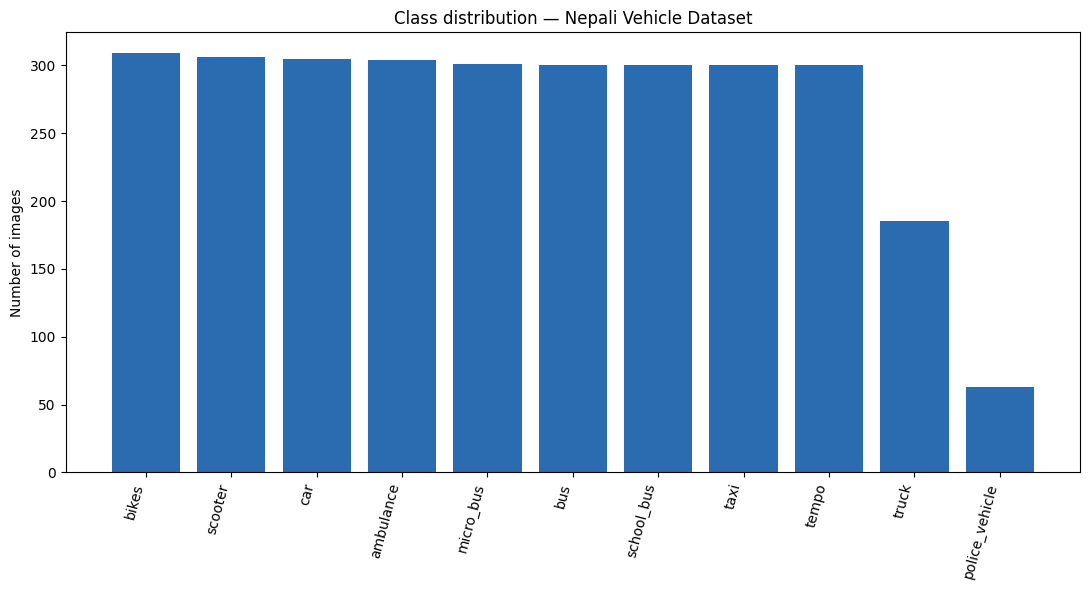

In [7]:
# Class distribution bar chart
sorted_items = sorted(counts.items(), key=lambda x: -x[1])
plt.figure(figsize=(11, 6))
plt.bar([k for k, _ in sorted_items], [v for _, v in sorted_items], color="#2b6cb0")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution — Nepali Vehicle Dataset")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "class_distribution.png", dpi=150)
plt.show()


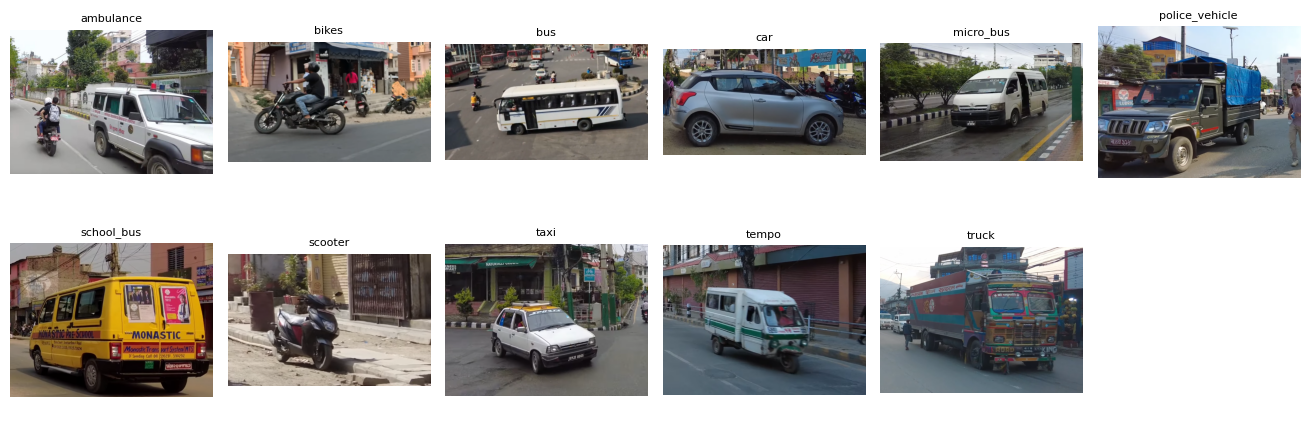

In [ ]:
# Sample grid, one image per class
classes_list = list(data_by_class.keys())
cols = 6
rows = (len(classes_list) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.4))
axes = axes.flatten()
for i, cls in enumerate(classes_list):
    ax = axes[i]
    files = data_by_class[cls]
    if files:
        try:
            img = Image.open(files[0]).convert("RGB")
            ax.imshow(img)
        except Exception:
            pass
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
for j in range(len(classes_list), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_grid.png", dpi=150)
plt.show()


Sampled 165 images.
Width : min=362 max=5315 mean=824
Height: min=229 max=4624 mean=586


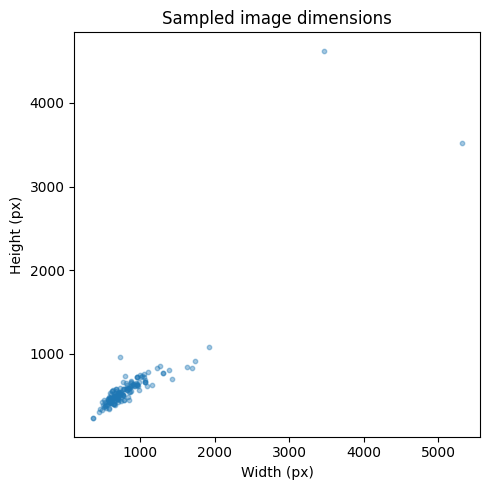

In [9]:
# Image size distribution (sampled)
widths, heights = [], []
for files in data_by_class.values():
    for p in files[:15]:
        try:
            with Image.open(p) as im:
                widths.append(im.width); heights.append(im.height)
        except Exception:
            continue

print(f"Sampled {len(widths)} images.")
print(f"Width : min={min(widths)} max={max(widths)} mean={np.mean(widths):.0f}")
print(f"Height: min={min(heights)} max={max(heights)} mean={np.mean(heights):.0f}")

plt.figure(figsize=(5,5))
plt.scatter(widths, heights, alpha=0.4, s=10)
plt.xlabel("Width (px)"); plt.ylabel("Height (px)")
plt.title("Sampled image dimensions")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "image_size_scatter.png", dpi=150)
plt.show()


## 4. Stratified Train / Val / Test Split (70 / 15 / 15)
 using a stratified split per class (seeded, so it's reproducible).


In [10]:
def create_splits(data_by_class, out_dir, train_size=0.70, val_size=0.15, seed=SEED, min_per_class=5):
    out_dir = Path(out_dir)
    skipped = []
    for cls, files in data_by_class.items():
        if len(files) < min_per_class:
            skipped.append((cls, len(files)))
            continue
        train_files, temp_files = train_test_split(files, train_size=train_size, random_state=seed)
        rel_val = val_size / (1 - train_size)
        val_files, test_files = train_test_split(temp_files, train_size=rel_val, random_state=seed)

        for split_name, split_files in [("train", train_files), ("val", val_files), ("test", test_files)]:
            dest = out_dir / split_name / cls
            dest.mkdir(parents=True, exist_ok=True)
            for f in split_files:
                shutil.copy2(f, dest / f.name)
        print(f"{cls:25s} train={len(train_files):4d} val={len(val_files):4d} test={len(test_files):4d}")

    if skipped:
        print("\nWARNING — classes skipped (too few images):")
        for name, n in skipped:
            print(f"  {name}: {n} images  (need >= {min_per_class})")
        print("Document any exclusion in the report's Data/Ethics section.")
    return skipped

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
skipped_classes = create_splits(data_by_class, SPLIT_DIR)

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "val"
TEST_DIR = SPLIT_DIR / "test"


ambulance                 train= 212 val=  45 test=  47
bikes                     train= 216 val=  46 test=  47
bus                       train= 210 val=  44 test=  46
car                       train= 213 val=  45 test=  47
micro_bus                 train= 210 val=  45 test=  46
police_vehicle            train=  44 val=   9 test=  10
school_bus                train= 210 val=  44 test=  46
scooter                   train= 214 val=  45 test=  47
taxi                      train= 210 val=  44 test=  46
tempo                     train= 210 val=  44 test=  46
truck                     train= 129 val=  27 test=  29


## 5. `ImageDataGenerator` Pipeline
Data augmentation is applied only to the **training** generator; validation/test use rescale-only,
deterministic preprocessing 


In [ ]:
BATCH_SIZE = 32

#  Generators for the from-scratch baseline CNN (expects [0,1] input) 
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest",
)
eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=SEED,
)
val_generator = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False,
)
test_generator = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False,
)

CLASSES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASSES)
assert train_generator.class_indices == val_generator.class_indices == test_generator.class_indices, \
    "Class-index mismatch between splits — check for a missing/extra class folder in one split."
print(f"\nNum classes: {NUM_CLASSES}")
print(f"Train/Val/Test sizes: {train_generator.samples}/{val_generator.samples}/{test_generator.samples}")

transfer_train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest",
)  # NOTE: no rescale=1./255 here
transfer_eval_datagen = ImageDataGenerator()  # NOTE: no rescale here either

transfer_train_generator = transfer_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=SEED,
)
transfer_val_generator = transfer_eval_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False,
)
transfer_test_generator = transfer_eval_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False,
)
assert transfer_train_generator.class_indices == train_generator.class_indices, \
    "Transfer generator class-index mapping doesn't match the baseline generator."


Found 2078 images belonging to 11 classes.
Found 438 images belonging to 11 classes.
Found 457 images belonging to 11 classes.

Num classes: 11
Train/Val/Test sizes: 2078/438/457
Found 2078 images belonging to 11 classes.
Found 438 images belonging to 11 classes.
Found 457 images belonging to 11 classes.


In [ ]:
# Class weights, computed on the TRAIN split, to counter the imbalance found in Section 3 
train_labels = train_generator.classes
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_labels
)
CLASS_WEIGHT_DICT = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights (balanced):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:20s} weight={CLASS_WEIGHT_DICT[i]:.3f}")


Class weights (balanced):
  ambulance            weight=0.891
  bikes                weight=0.875
  bus                  weight=0.900
  car                  weight=0.887
  micro_bus            weight=0.900
  police_vehicle       weight=4.293
  school_bus           weight=0.900
  scooter              weight=0.883
  taxi                 weight=0.900
  tempo                weight=0.900
  truck                weight=1.464


## 6. Model Architectures
Two supervised architectures are implemented and compared:

- **Baseline CNN** - a compact `Sequential` model (Conv2D-BatchNorm-ReLU-MaxPool ×4) trained from scratch.
  Establishes a from-scratch reference point.
- **Transfer Learning model** - an ImageNet-pretrained **EfficientNetB0** backbone with a new classifier
  head, fine-tuned in **two phases**: (1) backbone frozen, train only the head; (2) unfreeze the top
  backbone layers and fine-tune at a low learning rate. Justified because training a deep CNN from scratch
  on a small, scraped, 18-class Nepal-specific dataset risks severe overfitting , a pretrained backbone
  already encodes general edge/texture/shape features that transfer well.


In [13]:
def build_baseline_cnn(num_classes, dropout=0.4):
    model = models.Sequential([
        layers.Input(shape=IMG_SHAPE),

        layers.Conv2D(32, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(32, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(64, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(128, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(256, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(dropout),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ], name="BaselineCNN")
    return model


def build_transfer_model(num_classes, dropout=0.3):
    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SHAPE)
    base_model.trainable = False  # Phase 1: frozen backbone

    inputs = layers.Input(shape=IMG_SHAPE)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs, name="TransferLearning_EfficientNetB0")
    return model, base_model


baseline_cnn = build_baseline_cnn(NUM_CLASSES)
baseline_cnn.summary()

transfer_model, transfer_base = build_transfer_model(NUM_CLASSES)
transfer_model.summary()


Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,16

 Total params: 1,210,411 (4.62 MB)

 Trainable params: 1,208,491 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

...

Model: "TransferLearning_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,063,662 (15.50 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 7. Training  Baseline CNN
Applies **5 optimisation/regularisation techniques** (rubric requires ≥2): data augmentation, dropout, batch
normalisation, L2 weight decay, and `ReduceLROnPlateau` + `EarlyStopping`. Class-weighted loss is applied via
`class_weight=CLASS_WEIGHT_DICT` to counter the imbalance found in the EDA.




In [14]:
baseline_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_ckpt_path = str(MODELS_DIR / "baseline_best.keras")
baseline_callbacks = [
    callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint(baseline_ckpt_path, monitor="val_accuracy", mode="max", save_best_only=True),
]

baseline_history = baseline_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=CLASS_WEIGHT_DICT,
    callbacks=baseline_callbacks,
)

pd.DataFrame(baseline_history.history).to_csv(MODELS_DIR / "baseline_log.csv", index=False)
print(f"\nBest baseline checkpoint saved to: {baseline_ckpt_path}")


Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.1833 - loss: 2.3342 - val_accuracy: 0.1005 - val_loss: 2.6434 - learning_rate: 0.0010
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.2252 - loss: 2.1854 - val_accuracy: 0.1119 - val_loss: 2.4726 - learning_rate: 0.0010
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.2315 - loss: 2.1309 - val_accuracy: 0.1050 - val_loss: 2.9171 - learning_rate: 0.0010
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.2733 - loss: 2.0106 - val_accuracy: 0.1027 - val_loss: 3.9301 - learning_rate: 0.0010
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.2984 - loss: 1.9330 - val_accuracy: 0.1073 - val_loss: 2.7859 - learning_rate: 5.0000e-04
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.3306 - loss: 1.8219 - val_accuracy: 0.0913 - val_loss: 2.7638 - learning_rate: 5.0000e-04
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.3450 - loss: 1.7250 - val_a

## 8. Training Transfer Learning Model (EfficientNetB0)
**Phase 1:** backbone frozen, train only the new head.
**Phase 2:** unfreeze the top backbone layers, recompile with a much lower learning rate, and fine-tune.


In [15]:
# ---- Phase 1: frozen backbone ----
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_ckpt_path = str(MODELS_DIR / "transfer_best.keras")
phase1_callbacks = [
    callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint(transfer_ckpt_path, monitor="val_accuracy", mode="max", save_best_only=True),
]

print("=== Phase 1: training classifier head (backbone frozen) ===")
history_phase1 = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=8,
    class_weight=CLASS_WEIGHT_DICT,
    callbacks=phase1_callbacks,
)


=== Phase 1: training classifier head (backbone frozen) ===
Epoch 1/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6049 - loss: 1.4299 - val_accuracy: 0.8151 - val_loss: 0.7196 - learning_rate: 0.0010
Epoch 2/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8494 - loss: 0.6709 - val_accuracy: 0.8744 - val_loss: 0.4684 - learning_rate: 0.0010
Epoch 3/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8908 - loss: 0.4838 - val_accuracy: 0.9064 - val_loss: 0.3718 - learning_rate: 0.0010
Epoch 4/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8999 - loss: 0.4051 - val_accuracy: 0.9087 - val_loss: 0.3221 - learning_rate: 0.0010
Epoch 5/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9172 - loss: 0.3346 - val_accuracy: 0.9292 - val_loss: 0.2826 - learning_rate: 0.0010
Epoch 6/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9134 - loss: 0.3149 - val_accuracy: 0.9178 - val_loss: 0.2742 - learning_rate: 0.0010
Epoch 7/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/s

In [16]:
# ---- Phase 2: unfreeze top backbone layers, fine-tune at low LR ----
transfer_base.trainable = True
FINE_TUNE_AT = len(transfer_base.layers) - 30  # unfreeze roughly the last 30 layers only
for layer in transfer_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),  # 10x lower than Phase 1
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

phase2_callbacks = [
    callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=2, min_lr=1e-7),
    callbacks.ModelCheckpoint(transfer_ckpt_path, monitor="val_accuracy", mode="max", save_best_only=True),
]

print(f"=== Phase 2: fine-tuning top {len(transfer_base.layers) - FINE_TUNE_AT} backbone layers ===")
history_phase2 = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=20,
    class_weight=CLASS_WEIGHT_DICT,
    callbacks=phase2_callbacks,
)

# Combine both phases into one continuous history for plotting/reporting
transfer_history = {}
for key in history_phase1.history:
    transfer_history[key] = history_phase1.history[key] + history_phase2.history[key]
pd.DataFrame(transfer_history).to_csv(MODELS_DIR / "transfer_log.csv", index=False)
print(f"\nBest transfer-learning checkpoint saved to: {transfer_ckpt_path}")


=== Phase 2: fine-tuning top 30 backbone layers ===
Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.8614 - loss: 0.5072 - val_accuracy: 0.9155 - val_loss: 0.2263 - learning_rate: 1.0000e-04
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9216 - loss: 0.2854 - val_accuracy: 0.9201 - val_loss: 0.2090 - learning_rate: 1.0000e-04
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9302 - loss: 0.2247 - val_accuracy: 0.9224 - val_loss: 0.1930 - learning_rate: 1.0000e-04
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9480 - loss: 0.1747 - val_accuracy: 0.9338 - val_loss: 0.1739 - learning_rate: 1.0000e-04
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9572 - loss: 0.1515 - val_accuracy: 0.9406 - val_loss: 0.1670 - learning_rate: 1.0000e-04
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9639 - loss: 0.1198 - val_accuracy: 0.9452 - val_loss: 0.1547 - learning_rate: 1.0000e-04
Epoch 7/20
65/65 ━━━━━━

## 9. Loss / Accuracy Curves

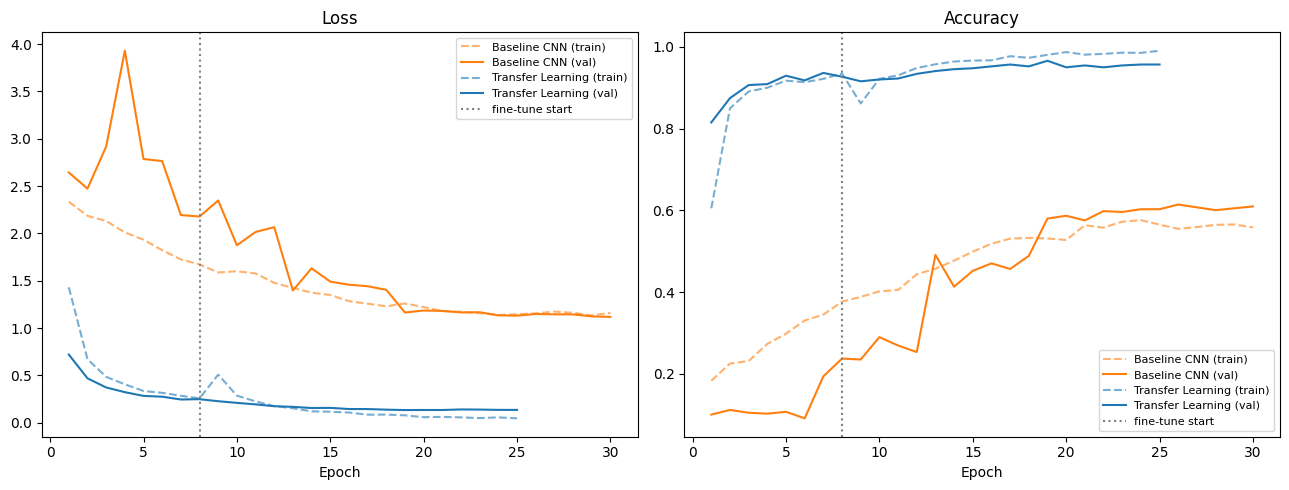

In [17]:
baseline_hist = pd.read_csv(MODELS_DIR / "baseline_log.csv")
transfer_hist = pd.read_csv(MODELS_DIR / "transfer_log.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for hist, label, color in [(baseline_hist, "Baseline CNN", "tab:orange"),
                            (transfer_hist, "Transfer Learning", "tab:blue")]:
    epochs_range = range(1, len(hist) + 1)
    axes[0].plot(epochs_range, hist["loss"], "--", color=color, alpha=0.6, label=f"{label} (train)")
    axes[0].plot(epochs_range, hist["val_loss"], "-", color=color, label=f"{label} (val)")
    axes[1].plot(epochs_range, hist["accuracy"], "--", color=color, alpha=0.6, label=f"{label} (train)")
    axes[1].plot(epochs_range, hist["val_accuracy"], "-", color=color, label=f"{label} (val)")

if len(history_phase1.history["loss"]) > 0:
    axes[0].axvline(len(history_phase1.history["loss"]), color="gray", linestyle=":", label="fine-tune start")
    axes[1].axvline(len(history_phase1.history["loss"]), color="gray", linestyle=":", label="fine-tune start")

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()


## 10. Full Evaluation on the Held-Out Test Set
Reports accuracy, macro-precision/recall/F1, the per-class report, and a confusion matrix - for **both**
models.


15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 691ms/step

=== baseline — Test Set Metrics ===
Accuracy       : 0.5842
Macro Precision: 0.5958
Macro Recall   : 0.5953
Macro F1       : 0.5605

                precision    recall  f1-score   support

     ambulance       0.45      0.30      0.36        47
         bikes       0.61      0.53      0.57        47
           bus       0.76      0.35      0.48        46
           car       0.65      0.36      0.47        47
     micro_bus       0.41      0.80      0.54        46
police_vehicle       0.28      0.70      0.40        10
    school_bus       0.88      0.98      0.93        46
       scooter       0.67      0.34      0.45        47
          taxi       0.81      0.74      0.77        46
         tempo       0.62      0.83      0.71        46
         truck       0.41      0.62      0.49        29

      accuracy                           0.58       457
     macro avg       0.60      0.60      0.56       457
  weighted avg       0.63      0.58   

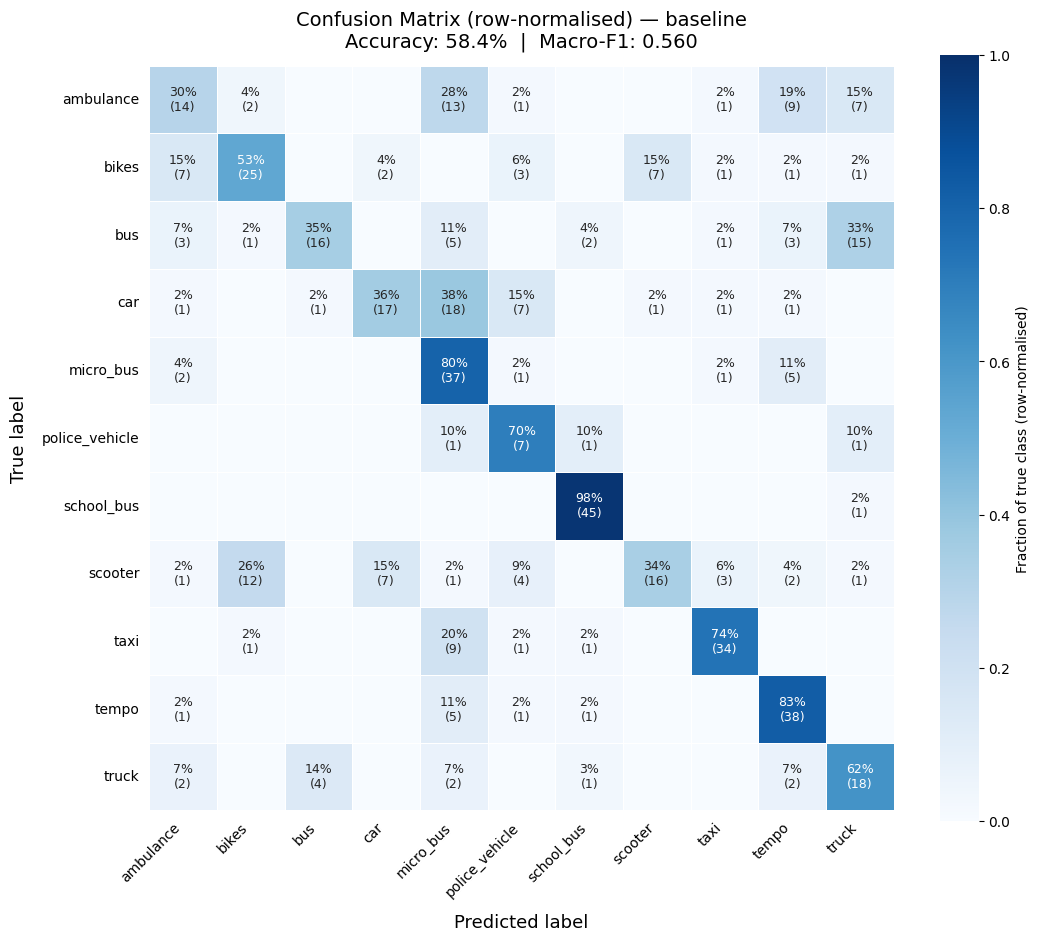

15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step

=== transfer — Test Set Metrics ===
Accuracy       : 0.9759
Macro Precision: 0.9792
Macro Recall   : 0.9784
Macro F1       : 0.9786

                precision    recall  f1-score   support

     ambulance       0.94      1.00      0.97        47
         bikes       0.98      0.96      0.97        47
           bus       1.00      0.96      0.98        46
           car       0.94      0.98      0.96        47
     micro_bus       1.00      0.98      0.99        46
police_vehicle       1.00      1.00      1.00        10
    school_bus       0.98      1.00      0.99        46
       scooter       0.96      0.98      0.97        47
          taxi       0.98      0.93      0.96        46
         tempo       1.00      0.98      0.99        46
         truck       1.00      1.00      1.00        29

      accuracy                           0.98       457
     macro avg       0.98      0.98      0.98       457
  weighted avg       0.98      0.98      

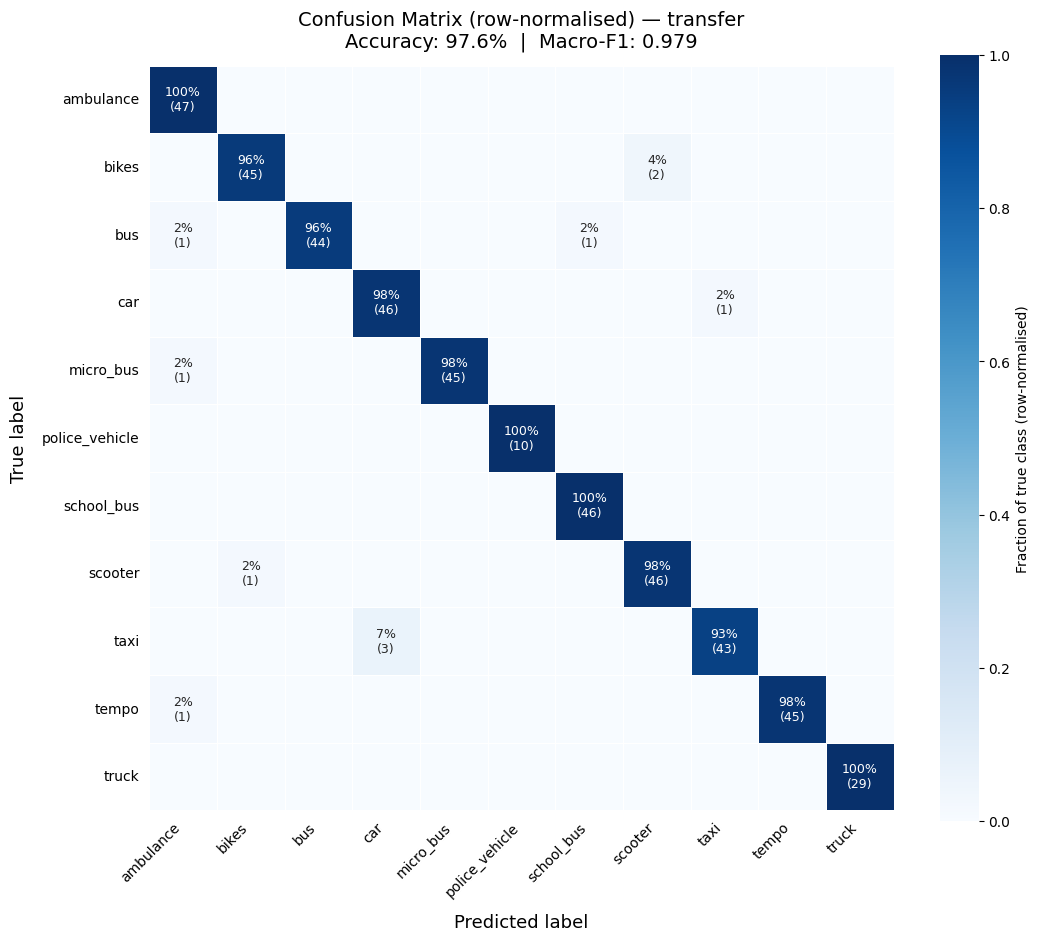

In [18]:
def evaluate_model(model, generator, tag):
    generator.reset()
    probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(probs, axis=1)
    y_true = generator.classes
    classes = list(generator.class_indices.keys())
    y_conf = probs.max(axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n=== {tag} — Test Set Metrics ===")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall   : {recall:.4f}")
    print(f"Macro F1       : {f1:.4f}\n")
    report_str = classification_report(y_true, y_pred, target_names=classes, zero_division=0)
    print(report_str)

    out_dir = RESULTS_DIR / tag
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / "metrics.json", "w") as f:
        json.dump({"model": tag, "accuracy": acc, "macro_precision": precision,
                    "macro_recall": recall, "macro_f1": f1}, f, indent=2)
    with open(out_dir / "classification_report.txt", "w") as f:
        f.write(report_str)

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    n_classes = len(classes)
    fig_size = max(11, n_classes * 0.75)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))

    # Annotate each cell with "row-normalised %\n(raw count)" so the figure is
    # readable on its own, without needing the raw cm printed separately.
    annot = np.empty_like(cm).astype(object)
    for i in range(n_classes):
        for j in range(n_classes):
            pct = cm_norm[i, j] * 100
            annot[i, j] = f"{pct:.0f}%\n({cm[i, j]})" if cm[i, j] > 0 else ""

    sns.heatmap(
        cm_norm, ax=ax, cmap="Blues", vmin=0, vmax=1,
        xticklabels=classes, yticklabels=classes,
        annot=annot, fmt="", annot_kws={"size": 9},
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Fraction of true class (row-normalised)"},
        square=True,
    )

    ax.set_xlabel("Predicted label", fontsize=13, labelpad=10)
    ax.set_ylabel("True label", fontsize=13, labelpad=10)
    ax.set_title(
        f"Confusion Matrix (row-normalised) — {tag}\n"
        f"Accuracy: {acc:.1%}  |  Macro-F1: {f1:.3f}",
        fontsize=14, pad=14,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.tick_params(left=False, bottom=False)

    plt.tight_layout()
    plt.savefig(out_dir / "confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    return dict(tag=tag, acc=acc, precision=precision, recall=recall, f1=f1,
                cm=cm, classes=classes, y_true=y_true, y_pred=y_pred, y_conf=y_conf,
                filenames=generator.filenames)

baseline_eval = evaluate_model(baseline_cnn, test_generator, tag="baseline")
transfer_eval = evaluate_model(transfer_model, transfer_test_generator, tag="transfer")


## 11. Error Analysis
For the **better-performing model**, this identifies the most-confused class pairs and visualises the most
confidently *wrong* predictions 


In [19]:
best_eval = transfer_eval if transfer_eval["f1"] >= baseline_eval["f1"] else baseline_eval
print(f"Running detailed error analysis on: {best_eval['tag']} (macro-F1={best_eval['f1']:.3f})")

classes = best_eval["classes"]
cm = best_eval["cm"].copy()
np.fill_diagonal(cm, 0)
confused_pairs = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if cm[i, j] > 0:
            confused_pairs.append((classes[i], classes[j], int(cm[i, j])))
confused_pairs.sort(key=lambda x: -x[2])

print("\nTop 10 most-confused class pairs (true -> predicted, count):")
for true_c, pred_c, n in confused_pairs[:10]:
    print(f"  {true_c:20s} -> {pred_c:20s} : {n}")

out_dir = RESULTS_DIR / best_eval["tag"]
with open(out_dir / "confused_pairs.json", "w") as f:
    json.dump(confused_pairs[:20], f, indent=2)


Running detailed error analysis on: transfer (macro-F1=0.979)

Top 10 most-confused class pairs (true -> predicted, count):
  taxi                 -> car                  : 3
  bikes                -> scooter              : 2
  bus                  -> ambulance            : 1
  bus                  -> school_bus           : 1
  car                  -> taxi                 : 1
  micro_bus            -> ambulance            : 1
  scooter              -> bikes                : 1
  tempo                -> ambulance            : 1


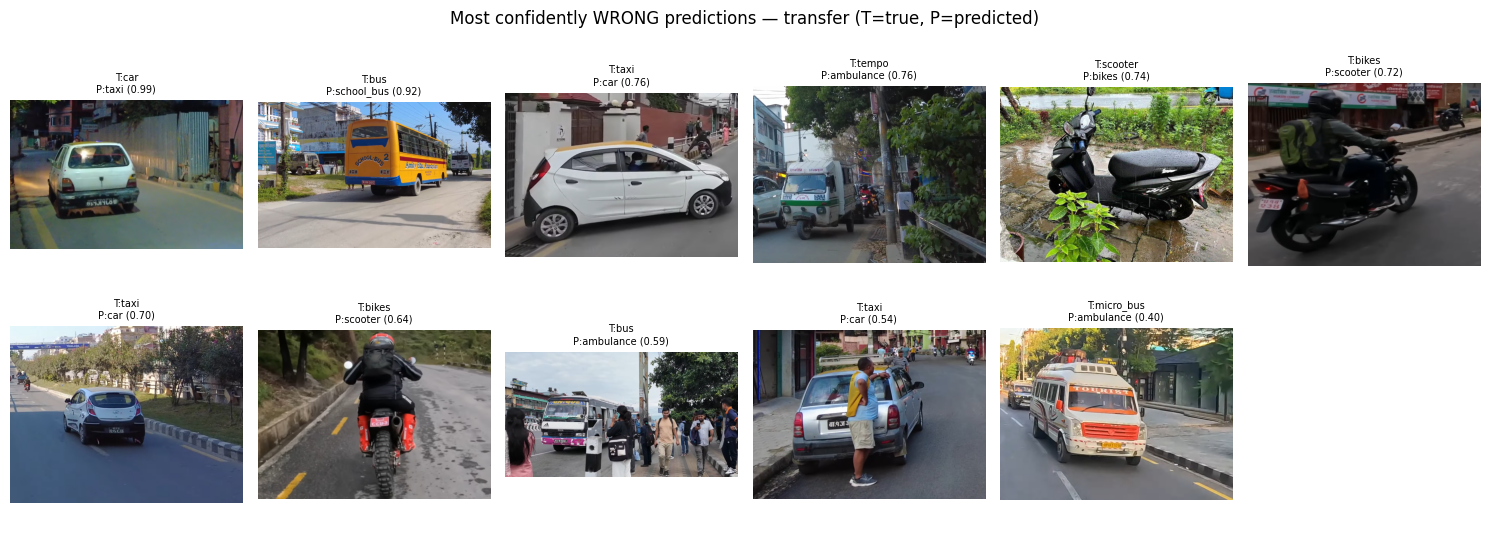

In [ ]:
# Grid of the most confidently WRONG predictions
y_true, y_pred, y_conf = best_eval["y_true"], best_eval["y_pred"], best_eval["y_conf"]
filenames = best_eval["filenames"]

wrong_idx = [i for i in range(len(y_true)) if y_pred[i] != y_true[i]]
wrong_idx.sort(key=lambda i: -y_conf[i])
top_wrong = wrong_idx[:24]

if top_wrong:
    cols = 6
    rows = (len(top_wrong) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.8))
    axes = axes.flatten()
    for ax, i in zip(axes, top_wrong):
        img_path = TEST_DIR / filenames[i]
        try:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
        except Exception:
            pass
        ax.set_title(f"T:{classes[y_true[i]]}\nP:{classes[y_pred[i]]} ({y_conf[i]:.2f})", fontsize=7)
        ax.axis("off")
    for ax in axes[len(top_wrong):]:
        ax.axis("off")
    plt.suptitle(f"Most confidently WRONG predictions - {best_eval['tag']} (T=true, P=predicted)")
    plt.tight_layout()
    plt.savefig(out_dir / "error_analysis_grid.png", dpi=150)
    plt.show()
else:
    print("No misclassifications on the test set (unlikely, but check evaluation code if this happens).")


## 12. Ablation Study
Trains restricted variants of the transfer-learning model (short, fixed epoch budget, Phase-1/frozen-backbone
only, for a fair and fast comparison) to isolate the individual contribution of each technique: augmentation,
dropout, class-weighted loss, and LR scheduling.


In [ ]:
ABLATION_VARIANTS = {
    "full":            dict(augment=True,  dropout=0.3, class_weighted=True,  lr_schedule=True),
    "no_augmentation": dict(augment=False, dropout=0.3, class_weighted=True,  lr_schedule=True),
    "no_dropout":      dict(augment=True,  dropout=0.0, class_weighted=True,  lr_schedule=True),
    "no_class_weight": dict(augment=True,  dropout=0.3, class_weighted=False, lr_schedule=True),
    "no_lr_schedule":  dict(augment=True,  dropout=0.3, class_weighted=True,  lr_schedule=False),
}
ABLATION_EPOCHS = 8  

# FIX: these variants train build_transfer_model() (EfficientNetB0), so  same as Section 8 
# they must NOT use rescale=1./255. Use non-rescaled generators, mirroring transfer_train_datagen /
# transfer_eval_datagen from Section 5.
no_aug_transfer_datagen = ImageDataGenerator()  # deterministic, no rescale, for the no-augmentation variant

def make_train_generator(augment: bool):
    gen = transfer_train_datagen if augment else no_aug_transfer_datagen
    return gen.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=True, seed=SEED,
    )

def run_ablation_variant(name, cfg, epochs=ABLATION_EPOCHS):
    set_seed()
    tl = make_train_generator(cfg["augment"])
    vl = transfer_eval_datagen.flow_from_directory(
        VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=False,
    )

    model, base = build_transfer_model(NUM_CLASSES, dropout=cfg["dropout"])
    base.trainable = False
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])

    cw = CLASS_WEIGHT_DICT if cfg["class_weighted"] else None
    cbs = [callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)] \
          if cfg["lr_schedule"] else []

    hist = model.fit(tl, validation_data=vl, epochs=epochs, class_weight=cw, callbacks=cbs, verbose=1)
    best_acc = max(hist.history["val_accuracy"])

    vl.reset()
    probs = model.predict(vl, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    y_true = vl.classes
    best_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return {"variant": name, "best_val_acc": round(float(best_acc), 4),
            "best_val_f1": round(float(best_f1), 4), **cfg}

ablation_results = []
for name, cfg in ABLATION_VARIANTS.items():
    print(f"\n=== Variant: {name} ===")
    ablation_results.append(run_ablation_variant(name, cfg))

ablation_df = pd.DataFrame(ablation_results).sort_values("best_val_f1", ascending=False)
ablation_df.to_csv(RESULTS_DIR / "ablation.csv", index=False)
ablation_df



=== Variant: full ===
Found 2078 images belonging to 11 classes.
Found 438 images belonging to 11 classes.
Epoch 1/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.5881 - loss: 1.4906 - val_accuracy: 0.8379 - val_loss: 0.7343 - learning_rate: 0.0010
Epoch 2/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8450 - loss: 0.6823 - val_accuracy: 0.8790 - val_loss: 0.4707 - learning_rate: 0.0010
Epoch 3/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8773 - loss: 0.4930 - val_accuracy: 0.8973 - val_loss: 0.3811 - learning_rate: 0.0010
Epoch 4/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9004 - loss: 0.3995 - val_accuracy: 0.9110 - val_loss: 0.3281 - learning_rate: 0.0010
Epoch 5/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9100 - loss: 0.3467 - val_accuracy: 0.9292 - val_loss: 0.2826 - learning_rate: 0.0010
Epoch 6/8
65/65 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9042 - loss: 0.3165 - val_accuracy: 0.9406 - val_loss: 0.2590 - learning_rate: 0.00

,variant,best_val_acc,best_val_f1,augment,dropout,class_weighted,lr_schedule
1,no_augmentation,0.9429,0.9440,False,0.3,True,True
3,no_class_weight,0.9429,0.9414,True,0.3,False,True
2,no_dropout,0.9384,0.9309,True,0.0,True,True
0,full,0.9406,0.9300,True,0.3,True,True
4,no_lr_schedule,0.9406,0.9300,True,0.3,True,False


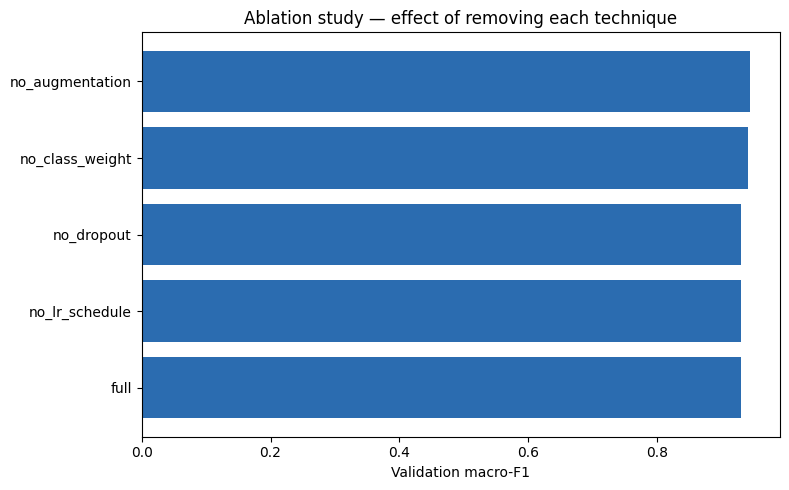


Use delta_f1_vs_full to report each technique's marginal contribution in the report's Results section:
           variant  best_val_f1  delta_f1_vs_full
1  no_augmentation       0.9440            0.0140
3  no_class_weight       0.9414            0.0114
2       no_dropout       0.9309            0.0009
0             full       0.9300            0.0000
4   no_lr_schedule       0.9300            0.0000


In [ ]:
# Visualise the marginal contribution of each technique relative to the full configuration
full_f1 = ablation_df.loc[ablation_df.variant == "full", "best_val_f1"].values[0]
ablation_df["delta_f1_vs_full"] = ablation_df["best_val_f1"] - full_f1

plt.figure(figsize=(8,5))
order = ablation_df.sort_values("best_val_f1")
plt.barh(order.variant, order.best_val_f1, color="#2b6cb0")
plt.xlabel("Validation macro-F1")
plt.title("Ablation study - effect of removing each technique")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablation_chart.png", dpi=150)
plt.show()

print("\nUse delta_f1_vs_full to report each technique's marginal contribution in the report's Results section:")
print(ablation_df[["variant", "best_val_f1", "delta_f1_vs_full"]])


## 13. Final Results Summary

In [23]:
summary = pd.DataFrame([
    {"Model": "Baseline CNN (from scratch)", "Accuracy": baseline_eval["acc"],
     "Macro Precision": baseline_eval["precision"], "Macro Recall": baseline_eval["recall"],
     "Macro F1": baseline_eval["f1"]},
    {"Model": "Transfer Learning (EfficientNetB0)", "Accuracy": transfer_eval["acc"],
     "Macro Precision": transfer_eval["precision"], "Macro Recall": transfer_eval["recall"],
     "Macro F1": transfer_eval["f1"]},
])
summary_display = summary.set_index("Model").round(4)
summary_display.to_csv(RESULTS_DIR / "final_summary.csv")
summary_display


,Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,
Baseline CNN (from scratch),0.5842,0.5958,0.5953,0.5605
Transfer Learning (EfficientNetB0),0.9759,0.9792,0.9784,0.9786


## 14. Save Everything to Google Drive


In [24]:
DRIVE_OUT = Path("/content/drive/MyDrive/CSC60904_NepaliVehicleDL")
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

shutil.copytree(MODELS_DIR, DRIVE_OUT / "models", dirs_exist_ok=True)
shutil.copytree(RESULTS_DIR, DRIVE_OUT / "results", dirs_exist_ok=True)
print(f"Saved models and results to: {DRIVE_OUT}")


Saved models and results to: /content/drive/MyDrive/CSC60904_NepaliVehicleDL


## 15. Quick Inference Demo (upload a photo, get a prediction)
A lightweight stand-in for a Streamlit demo  useful for a quick live demo during the presentation.


Upload an image of a vehicle to classify:


Saving images (5).jpg to images (5).jpg


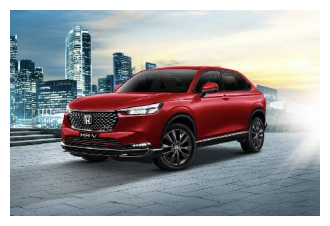


Top-3 predictions:
  car                  100.0%
  scooter              0.0%
  bikes                0.0%


In [ ]:
from google.colab import files as gfiles

def predict_image(model, classes, pil_image):
    # FIX: transfer_model (EfficientNetB0) expects raw [0,255] pixels its internal
    # Rescaling/Normalization layer does the scaling. Do NOT divide by 255 here.
    img = pil_image.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    x = img_to_array(img)  
    x = np.expand_dims(x, axis=0)
    probs = model.predict(x, verbose=0)[0]
    top_idx = probs.argsort()[-3:][::-1]
    return [(classes[i], float(probs[i])) for i in top_idx]

print("Upload an image of a vehicle to classify:")
uploaded_img = gfiles.upload()
img_path = list(uploaded_img.keys())[0]
pil_img = Image.open(img_path)

plt.figure(figsize=(4,4)); plt.imshow(pil_img); plt.axis("off"); plt.show()

results = predict_image(transfer_model, transfer_eval["classes"], pil_img)
print("\nTop-3 predictions:")
for label, conf in results:
    print(f"  {label:20s} {conf*100:.1f}%")
if results[0][1] < 0.5:
    print("\n[LOW CONFIDENCE] - flag for manual review rather than trusting automatically.")
